In [ ]:
!file extracted_features_dog_color_glcm_lbp_lbglcm_glrlm_sfta.npz

extracted_features_dog_color_glcm_lbp_lbglcm_glrlm_sfta.npz: Zip archive data, at least v4.5 to extract, compression method=deflate


In [ ]:
import numpy as np
npz_data = np.load("extracted_features_dog_color_glcm_lbp_lbglcm_glrlm_sfta.npz")

print("Keys available in the .npz file:", npz_data.files)
print("Data loaded into 'npz_data' variable.")

Keys available in the .npz file: ['X', 'Y']
Data loaded into 'npz_data' variable.


In [ ]:
import numpy as np
X = npz_data['X']
y = npz_data['Y']

print(X.shape)
print(y.shape)

(220025, 51)
(220025,)


##  **1. Data Sampling**

We select 15,000 stratified samples for faster training.

In [ ]:
from sklearn.model_selection import train_test_split

X_small, _, y_small, _ = train_test_split(
    X, y,
    train_size=15000,
    stratify=y,
    random_state=42
)

print(X_small.shape)
print(y_small.shape)

(15000, 51)
(15000,)


## **2. Model Comparison**

We evaluate multiple machine learning models including Logistic Regression, Random Forest, SVM, KNN, and Decision Tree using cross-validation.

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.metrics import classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# --------------------------------------
# Evaluate
# --------------------------------------
for name, model in models.items():

    print("="*60)
    print(f"MODEL: {name}")
    print("="*60)

    # Accuracy Fold
    scores = cross_validate(
        model, X_small, y_small,
        cv=cv,
        scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
        n_jobs=-1
    )

    print("AccuracyFold:")
    print(scores['test_accuracy'])

    print("\nMean Accuracy:", scores['test_accuracy'].mean())

    print("\nMean Precision:", scores['test_precision_macro'].mean())
    print("Mean Recall   :", scores['test_recall_macro'].mean())
    print("Mean F1 Score :", scores['test_f1_macro'].mean())

    # Classification Report
    y_pred = cross_val_predict(model, X_small, y_small, cv=cv, n_jobs=-1)

    print("\nClassification Report:")
    print(classification_report(y_small, y_pred))

    print("\n")

MODEL: Logistic Regression
AccuracyFold:
[0.814      0.79466667 0.80933333 0.803      0.80966667]

Mean Accuracy: 0.8061333333333334

Mean Precision: 0.8004304226447939
Mean Recall   : 0.7943783933326417
Mean F1 Score : 0.7969346103378235

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.86      0.84      8925
           1       0.78      0.73      0.75      6075

    accuracy                           0.81     15000
   macro avg       0.80      0.79      0.80     15000
weighted avg       0.81      0.81      0.81     15000



MODEL: Random Forest
AccuracyFold:
[0.84866667 0.83266667 0.85733333 0.834      0.84066667]

Mean Accuracy: 0.8426666666666668

Mean Precision: 0.8406911638512906
Mean Recall   : 0.8302562506484076
Mean F1 Score : 0.8344239105477097

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      8925
           1       0.83      0.76      0.8

##  **Results Analysis**

While increasing the dataset size, Random Forest showed the most noticeable improvement compared to other models.

However, for consistency and faster experimentation, all models were evaluated on a fixed sample size of 15,000.

Overall, Random Forest achieved the best performance, followed by Logistic Regression, while SVM, KNN, and Decision Tree showed lower results.

## **3.Feature Scaling Comparison**

We compare **StandardScaler and MinMaxScaler** with different models (Logistic Regression, SVM, and KNN) to study their effect on performance.

In [ ]:
#  Scaling Comparison
# StandardScaler vs MinMaxScaler

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# ------------------------------------------
# Cross Validation
# ------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------
# Models
# ------------------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# ------------------------------------------
# Scalers
# ------------------------------------------
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

# ------------------------------------------
# Evaluate
# ------------------------------------------
for scaler_name, scaler in scalers.items():

    for model_name, model in models.items():

        pipe = Pipeline([
            ('scaler', scaler),
            ('model', model)
        ])

        print("=" * 70)
        print(f"SCALER: {scaler_name} | MODEL: {model_name}")
        print("=" * 70)

        # Cross Validation Scores
        scores = cross_validate(
            pipe,
            X_small,
            y_small,
            cv=cv,
            scoring='accuracy',
            return_train_score=True,
            n_jobs=-1
        )

        # Train Accuracy
        print("Train Accuracy Fold:")
        print(scores['train_score'])

        print("\nMean Train Accuracy:",
              scores['train_score'].mean())

        # Test Accuracy
        print("\nTest Accuracy  for each Fold:")
        print(scores['test_score'])

        print("\nMean Test Accuracy:",
              scores['test_score'].mean())

        # Predictions for Report
        y_pred = cross_val_predict(
            pipe,
            X_small,
            y_small,
            cv=cv,
            n_jobs=-1
        )

        # Classification Report
        print("\nClassification Report:\n")
        print(classification_report(y_small, y_pred))

        print("\n")

SCALER: StandardScaler | MODEL: Logistic Regression
Train Accuracy Fold:
[0.82275    0.82391667 0.82158333 0.82233333 0.82291667]

Mean Train Accuracy: 0.8227

Test Accuracy  for each Fold:
[0.82366667 0.80933333 0.82733333 0.82066667 0.822     ]

Mean Test Accuracy: 0.8206

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.87      0.85      8925
           1       0.79      0.75      0.77      6075

    accuracy                           0.82     15000
   macro avg       0.82      0.81      0.81     15000
weighted avg       0.82      0.82      0.82     15000



SCALER: StandardScaler | MODEL: SVM
Train Accuracy Fold:
[0.84858333 0.84908333 0.84541667 0.848      0.84608333]

Mean Train Accuracy: 0.8474333333333334

Test Accuracy  for each Fold:
[0.84       0.83033333 0.84666667 0.836      0.84333333]

Mean Test Accuracy: 0.8392666666666667

Classification Report:

              precision    recall  f1-score   support

        

##  **Results Analysis**

Scaling significantly improved model performance, especially for SVM and KNN.

StandardScaler achieved the best results overall, **with SVM reaching performance comparable to Random Forest.**

MinMaxScaler also improved results but was slightly less effective than StandardScaler.

Overall, scaling is essential for distance-based and margin-based models.

## **4.Feature Selection**

We apply SelectKBest to select the most important features and evaluate its impact on different models using various values of k.

In [ ]:
# STEP 3: Feature Selection (SelectKBest)

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

# ------------------------------------------
# Cross Validation
# ------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------
# Models
# ------------------------------------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}


k_values = [10, 20, 30, 40, 51]


results = []

# ------------------------------------------
# Loop over K and Models
# ------------------------------------------
for k in k_values:
    selector = SelectKBest(score_func=f_classif, k=k)

    for model_name, model in models.items():

        pipe = Pipeline([
            ('select', selector),
            ('model', model)
        ])

        scores = cross_val_score(pipe, X_small, y_small,
                                 cv=cv,
                                 scoring='accuracy',
                                 n_jobs=-1)

        results.append({
            "K Features": k,
            "Model": model_name,
            "Mean Accuracy": scores.mean(),
            "Std": scores.std()
        })

# ------------------------------------------
# Show Results
# ------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Mean Accuracy", ascending=False)

print(results_df)

    K Features                Model  Mean Accuracy       Std
12          51        Random Forest       0.842667  0.009276
6           30        Random Forest       0.842600  0.004832
9           40        Random Forest       0.840400  0.004982
3           20        Random Forest       0.822200  0.006953
14          51  Logistic Regression       0.806133  0.006722
11          40  Logistic Regression       0.804933  0.003861
0           10        Random Forest       0.801200  0.006904
8           30  Logistic Regression       0.794733  0.004090
13          51                  SVM       0.793667  0.004017
10          40                  SVM       0.792600  0.002954
7           30                  SVM       0.784733  0.005405
5           20  Logistic Regression       0.767200  0.006503
2           10  Logistic Regression       0.740000  0.006429
4           20                  SVM       0.613933  0.005694
1           10                  SVM       0.613400  0.005855


## **Results Analysis**

All models achieved their highest performance when using all 51 features, confirming that the original feature extraction was effective.

Reducing the number of features did not improve performance, so feature selection will not be applied.

##  **5.PCA Experiment**

We apply PCA with different numbers of components to reduce dimensionality and evaluate its effect on model performance using StandardScaler with SVM, Logistic Regression, and Random Forest classifiers.

In [ ]:
# STEP 4: PCA Comparison
# StandardScaler + PCA + Models

import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------
# Cross Validation
# ------------------------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ------------------------------------------
# Models
# ------------------------------------------
models = {
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# ------------------------------------------
# PCA values
# ------------------------------------------
pca_values = [10, 20, 30, 40, 0.95]


results = []

for pca_val in pca_values:

    for model_name, model in models.items():

        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=pca_val)),
            ('model', model)
        ])

        scores = cross_val_score(
            pipe,
            X_small,
            y_small,
            cv=cv,
            scoring='accuracy',
            n_jobs=-1
        )

        results.append({
            "PCA Components": pca_val,
            "Model": model_name,
            "Mean Accuracy": scores.mean(),
            "Std": scores.std()
        })

# ------------------------------------------
# Results
# ------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Mean Accuracy", ascending=False)

print(results_df)

    PCA Components                Model  Mean Accuracy       Std
11           40.00        Random Forest       0.839800  0.005390
8            30.00        Random Forest       0.839467  0.005636
9            40.00                  SVM       0.838467  0.005946
6            30.00                  SVM       0.834067  0.005817
5            20.00        Random Forest       0.829000  0.006349
14            0.95        Random Forest       0.821267  0.004424
3            20.00                  SVM       0.820467  0.006755
10           40.00  Logistic Regression       0.818667  0.005602
12            0.95                  SVM       0.816200  0.006866
7            30.00  Logistic Regression       0.815533  0.005663
2            10.00        Random Forest       0.814000  0.004269
0            10.00                  SVM       0.807400  0.006884
4            20.00  Logistic Regression       0.792800  0.003557
13            0.95  Logistic Regression       0.782600  0.005825
1            10.00  Logis

## **Results Analysis**

**SVM** was the only model that clearly benefited from PCA, especially at 40 components, where it became competitive with Random Forest.

Random Forest remained the most stable top performer across settings.

Therefore, we will continue the experiments using **SVM (with PCA40) and Random Forest as the final candidate models.**

##**6.Hyperparameter tuning**

In [ ]:
# Random Forest Hyperparameter Tuning


import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

# ------------------------------------------
# Cross Validation
# ------------------------------------------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ------------------------------------------
# Base Model
# ------------------------------------------
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# ------------------------------------------
# Hyperparameter Grid
# ------------------------------------------
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# ------------------------------------------
# Random Search
# ------------------------------------------
search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------
# Train Search
# ------------------------------------------
search.fit(X_small, y_small)

# ------------------------------------------
# Best Results
# ------------------------------------------
print("Best Accuracy :", search.best_score_)
print("\nBest Parameters:\n")
print(search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Accuracy : 0.8413333333333334

Best Parameters:

{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 20}


##**Results Analysis**
Hyperparameter tuning improved Random Forest and confirmed it as the best model with the optimized parameters.

In [ ]:
# STEP 6: Hyperparameter Tuning
# StandardScaler + PCA(40) + SVM


import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC

# ------------------------------------------
# CV
# ------------------------------------------
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# ------------------------------------------
# Pipeline
# ------------------------------------------
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=40)),
    ('svm', SVC())
])

# ------------------------------------------
# Hyperparameter Grid
# ------------------------------------------
param_grid = {
    'svm__C': [0.1, 1, 10, 20],
    'svm__gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ------------------------------------------
# Search
# ------------------------------------------
search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_grid,
    n_iter=10,
    scoring='accuracy',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------
# Fit
# ------------------------------------------
search.fit(X_small, y_small)

# ------------------------------------------
# Results
# ------------------------------------------
print("Best Accuracy:", search.best_score_)
print("\nBest Parameters:\n")
print(search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Accuracy: 0.8485333333333333

Best Parameters:

{'svm__kernel': 'rbf', 'svm__gamma': 0.01, 'svm__C': 10}


In [ ]:
!pip install scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.4 MB/s eta 0:00:00


##**Results Analysis**

Hyperparameter tuning improved the SVM model and showed that the PCA-based SVM becomes highly competitive with Random Forest.

The best configuration uses an RBF kernel with optimized C and gamma values, confirming SVM as a strong final candidate model.

##  **7. Tuned Models: SVM & Random Forest (Best Hyperparameters)**

##**SVM (Best Hyperparameters from Randomized Search)**

In [ ]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# ------------------------------------------
# 1. Train / Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

# ------------------------------------------
# 2. Pipeline: Scaling + PCA + SVM (Balanced)
# ------------------------------------------
model = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=40)),
    ('svm', SVC(
        kernel='rbf',
        C=10,
        gamma=0.01,
        class_weight='balanced'
    ))
])

# ------------------------------------------
# 3. Train
# ------------------------------------------
model.fit(X_train, y_train)

# ------------------------------------------
# 4. Predictions
# ------------------------------------------
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# ------------------------------------------
# 5. Accuracy
# ------------------------------------------
print("="*60)
print("ACCURACY")
print("="*60)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

# ------------------------------------------
# 6. Classification Report
# ------------------------------------------
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TEST)")
print("="*60)

print(classification_report(y_test, y_test_pred))

ACCURACY
Train Accuracy: 0.86
Test Accuracy : 0.845

CLASSIFICATION REPORT (TEST)
              precision    recall  f1-score   support

           0       0.90      0.83      0.86      1785
           1       0.78      0.86      0.82      1215

    accuracy                           0.84      3000
   macro avg       0.84      0.85      0.84      3000
weighted avg       0.85      0.84      0.85      3000



## **Results Analysis**

The **SVM pipeline** shows consistent performance between training and testing sets, indicating **good generalization** on the sampled data.
.

## **Random Forest (Best Hyperparameters from from Randomized Search)**


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# ------------------------------------------
# 1. Train / Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

# ------------------------------------------
# 2. Model
# ------------------------------------------
RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------
# 3. Train
# ------------------------------------------
rf.fit(X_train, y_train)

# ------------------------------------------
# 4. Predictions
# ------------------------------------------
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# ------------------------------------------
# 5. Accuracy
# ------------------------------------------
print("="*60)
print("RANDOM FOREST ACCURACY")
print("="*60)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

# ------------------------------------------
# 6. Classification Report
# ------------------------------------------
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TEST)")
print("="*60)

print(classification_report(y_test, y_test_pred))

RANDOM FOREST ACCURACY
Train Accuracy: 0.9915833333333334
Test Accuracy : 0.8416666666666667

CLASSIFICATION REPORT (TEST)
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1785
           1       0.82      0.77      0.80      1215

    accuracy                           0.84      3000
   macro avg       0.84      0.83      0.83      3000
weighted avg       0.84      0.84      0.84      3000



## **Results Analysis**

The Random Forest model shows strong training performance with a small drop on the test set, indicating slight overfitting but still good.

## **Random Forest (Best Hyperparameters from Bayesian Optimization)**


In [ ]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# ------------------------------------------
# 1. Train / Test Split
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_small, y_small,
    test_size=0.2,
    random_state=42,
    stratify=y_small
)

# ------------------------------------------
# 2. Model
# ------------------------------------------
rf = RandomForestClassifier(
    n_estimators=189,
    max_depth=37,
    min_samples_split=9,
    min_samples_leaf=4,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------
# 3. Train
# ------------------------------------------
rf.fit(X_train, y_train)

# ------------------------------------------
# 4. Predictions
# ------------------------------------------
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)

# ------------------------------------------
# 5. Accuracy
# ------------------------------------------
print("="*60)
print("RANDOM FOREST ACCURACY")
print("="*60)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

# ------------------------------------------
# 6. Classification Report
# ------------------------------------------
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TEST)")
print("="*60)

print(classification_report(y_test, y_test_pred))

RANDOM FOREST ACCURACY
Train Accuracy: 0.97175
Test Accuracy : 0.844

CLASSIFICATION REPORT (TEST)
              precision    recall  f1-score   support

           0       0.86      0.89      0.87      1785
           1       0.82      0.78      0.80      1215

    accuracy                           0.84      3000
   macro avg       0.84      0.83      0.84      3000
weighted avg       0.84      0.84      0.84      3000



## **Results Analysis**

Test accuracy slightly increased, and overfitting was reduced after tuning.

##full data

In [ ]:
#Best Bayesian search Forest Model
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# ------------------------------------------
# 1. Train / Test Split (FULL DATA)
# ------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------
# 2. Best Random Forest Model
# ------------------------------------------
model =RandomForestClassifier(
    n_estimators=189,
    max_depth=37,
    min_samples_split=9,
    min_samples_leaf=4,
    max_features=None,
    random_state=42,
    n_jobs=-1
)

# ------------------------------------------
# 3. Train
# ------------------------------------------
model.fit(X_train, y_train)

# ------------------------------------------
# 4. Predictions
# ------------------------------------------
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# ------------------------------------------
# 5. Accuracy
# ------------------------------------------
print("="*60)
print("RANDOM FOREST FINAL MODEL ACCURACY")
print("="*60)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

# ------------------------------------------
# 6. Classification Report
# ------------------------------------------
print("\n" + "="*60)
print("CLASSIFICATION REPORT (TEST)")
print("="*60)

print(classification_report(y_test, y_test_pred))

RANDOM FOREST FINAL MODEL ACCURACY
Train Accuracy: 0.9813373480286331
Test Accuracy : 0.8902624701738439

CLASSIFICATION REPORT (TEST)
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     26182
           1       0.88      0.84      0.86     17823

    accuracy                           0.89     44005
   macro avg       0.89      0.88      0.89     44005
weighted avg       0.89      0.89      0.89     44005



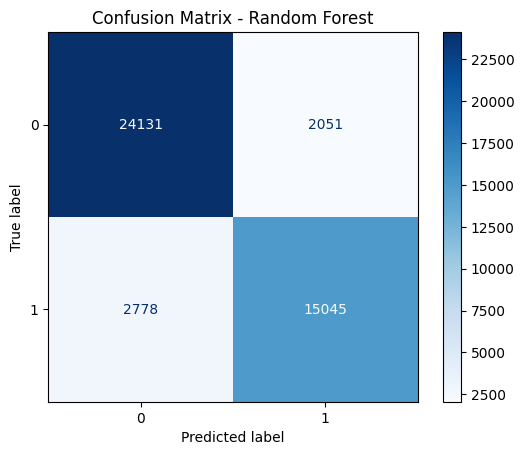

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

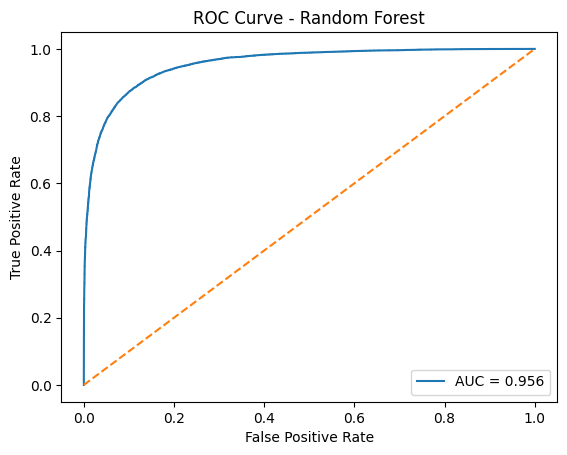

In [ ]:
from sklearn.metrics import roc_curve, auc

# probabilities (important for ROC)
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], '--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()